In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from scipy.signal import find_peaks
from scipy.special import j1

In [19]:
lam400 = "#8200b5" # Hex color code for 400nm wavelength (violet)
lam500 = "#00ff92"  # Hex color code for 500nm wavelength (greenish)
lam600 = "#ffbe00" # Hex color code for 600nm wavelength (yellow)

# https://academo.org/demos/wavelength-to-colour-relationship/

# Vertical Single Slit

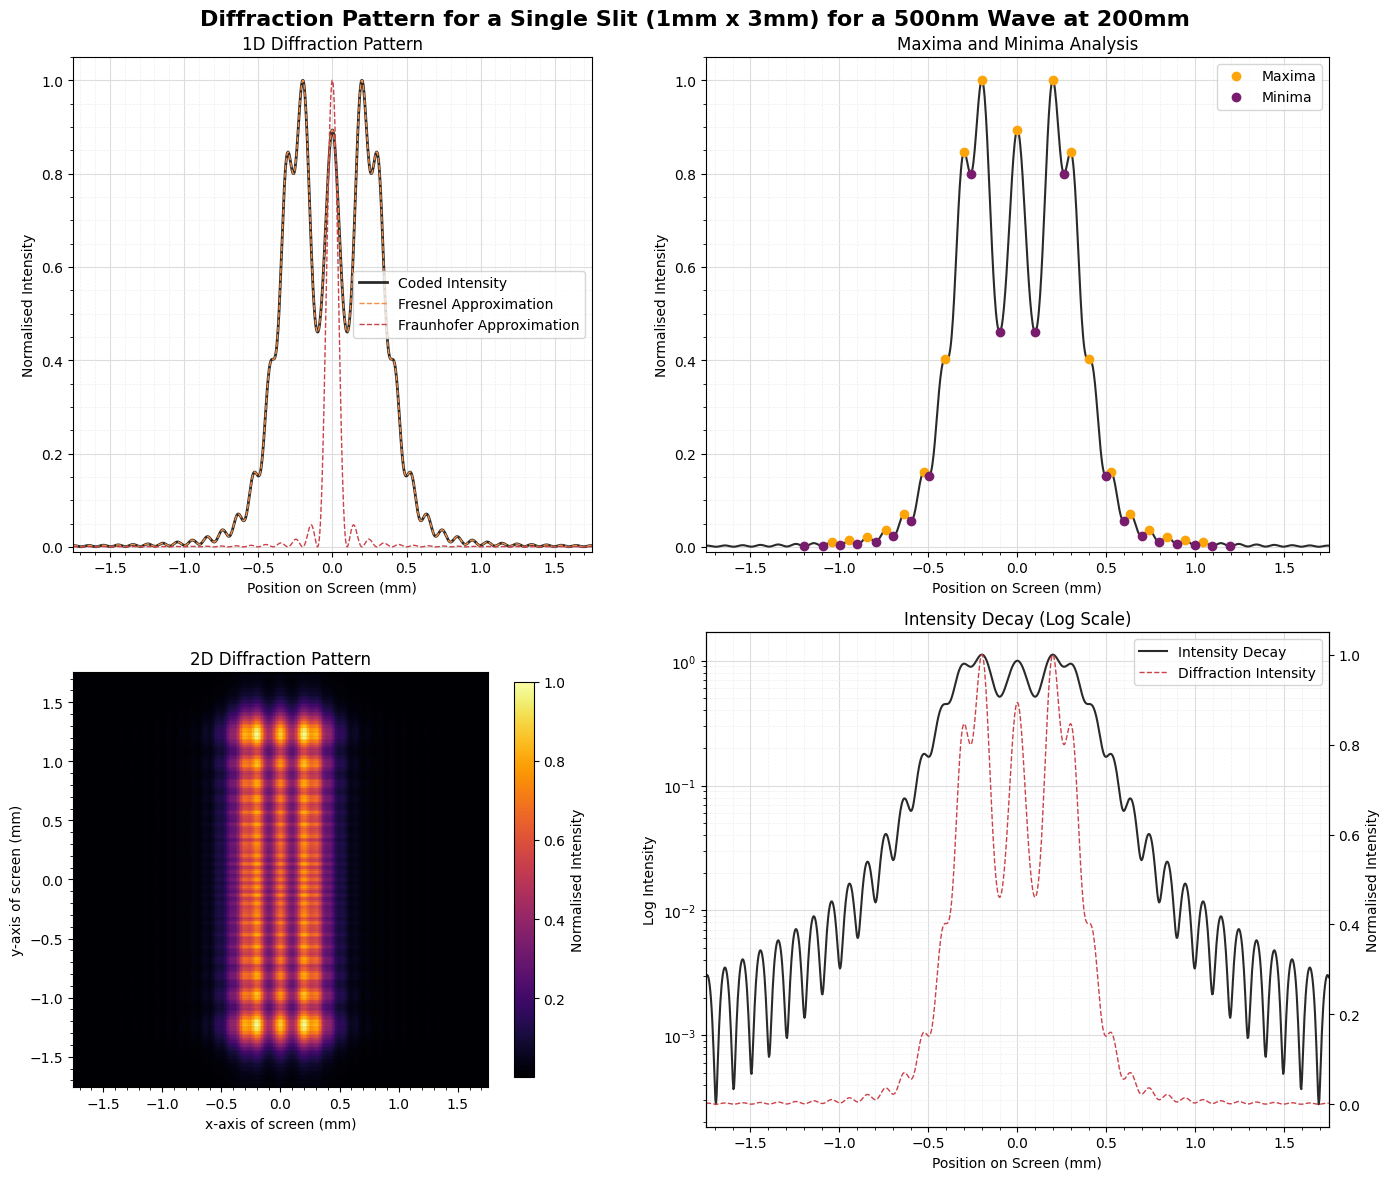

In [20]:
# Wave Equation and Properties

w, h = 1e-3, 3e-3
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 300, 900
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = (np.abs(xx_ap) <= w/2) & (np.abs(yy_ap) <= h/2)

xx_ap_srect = xx_ap[mask].ravel()
yy_ap_srect = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_srect, yy_ap_srect), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def fraun_srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000): 

    screen = np.linspace(screen[0], screen[1], points) 
    
    theta = np.arctan(screen / L) 
    beta = (np.pi * w / lam) * np.sin(theta) 
    
    I_fraun = (np.sinc(beta/np.pi)**2)
    I_fraun /= I_fraun.max() 

    return screen, I_fraun

def fresnel_srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)
    factor = (np.exp(1j * k * L)) / (1j * lam * L) # Fresnel Approximation 

    xp = aperture_points[:,0]
    yp = aperture_points[:,1]

    E_theory = np.zeros_like(screen, dtype=complex)
    for i, x in enumerate(screen):
        phase = np.exp((1j * k)/(2 * L) * ((x - xp)**2 + yp**2)) # Fresnel Approximation (Integral Part)
        E = phase * area
        E_theory[i] = factor * E.sum()

    I_fresnel = (np.abs(E_theory)**2)
    I_fresnel /= I_fresnel.max()

    return screen, I_fresnel

def srect_2d(screen=(-1.75e-3, 1.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = srect_1d()
screen, I1DF = fresnel_srect_1d()
screen, I1DFh = fraun_srect_1d()
X, Y, I2D = srect_2d()

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Pattern for a Single Slit (1mm x 3mm) for a 500nm Wave at 200mm', fontsize=16, fontweight='bold')

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=2, label='Coded Intensity')
axes[0,0].plot(screen * 1e3, I1DF, '--', color='#f68d45', linewidth=1, label='Fresnel Approximation')
axes[0,0].plot(screen * 1e3, I1DFh, '--', color='#cb4149', linewidth=1, label='Fraunhofer Approximation')

axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([-0.01, 1.05])
axes[0,0].set_xlim([-1.75, 1.75])

axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,0].legend()

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto', cmap='inferno')
axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], 'o', color="#fca50a", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], 'o', color="#781c6d", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([-0.01, 1.05])
axes[0,1].set_xlim([-1.75, 1.75])

axes[0,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Intensity Decay Log Plot; bottom right
centre = np.argmin(np.abs(screen))
centre_peak = I1D[centre]

I1D_norm = I1D / centre_peak

mask = I1D_norm > 1e-12

ax_log = axes[1,1]

ax_log.semilogy(screen * 1e3, I1D_norm[mask], color="#2A2A2A", linewidth=1.5, label='Intensity Decay')
ax_log.set_ylabel('Log Intensity')
ax_log.tick_params(axis='y')

ax_lin = ax_log.twinx()
ax_lin.plot(screen * 1e3, I1D, '--', color='#cb4149', linewidth=1, label='Diffraction Intensity')
ax_lin.set_ylabel('Normalised Intensity')
ax_lin.tick_params(axis='y')

ax_log.set_xlabel('Position on Screen (mm)')
ax_log.set_title('Intensity Decay (Log Scale)')
ax_log.set_xlim([-1.75,1.75])

ax_log.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax_log.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax_log.minorticks_on()

lines1, labels1 = ax_log.get_legend_handles_labels()
lines2, labels2 = ax_lin.get_legend_handles_labels()
ax_log.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()

# Horizontal Single Slit

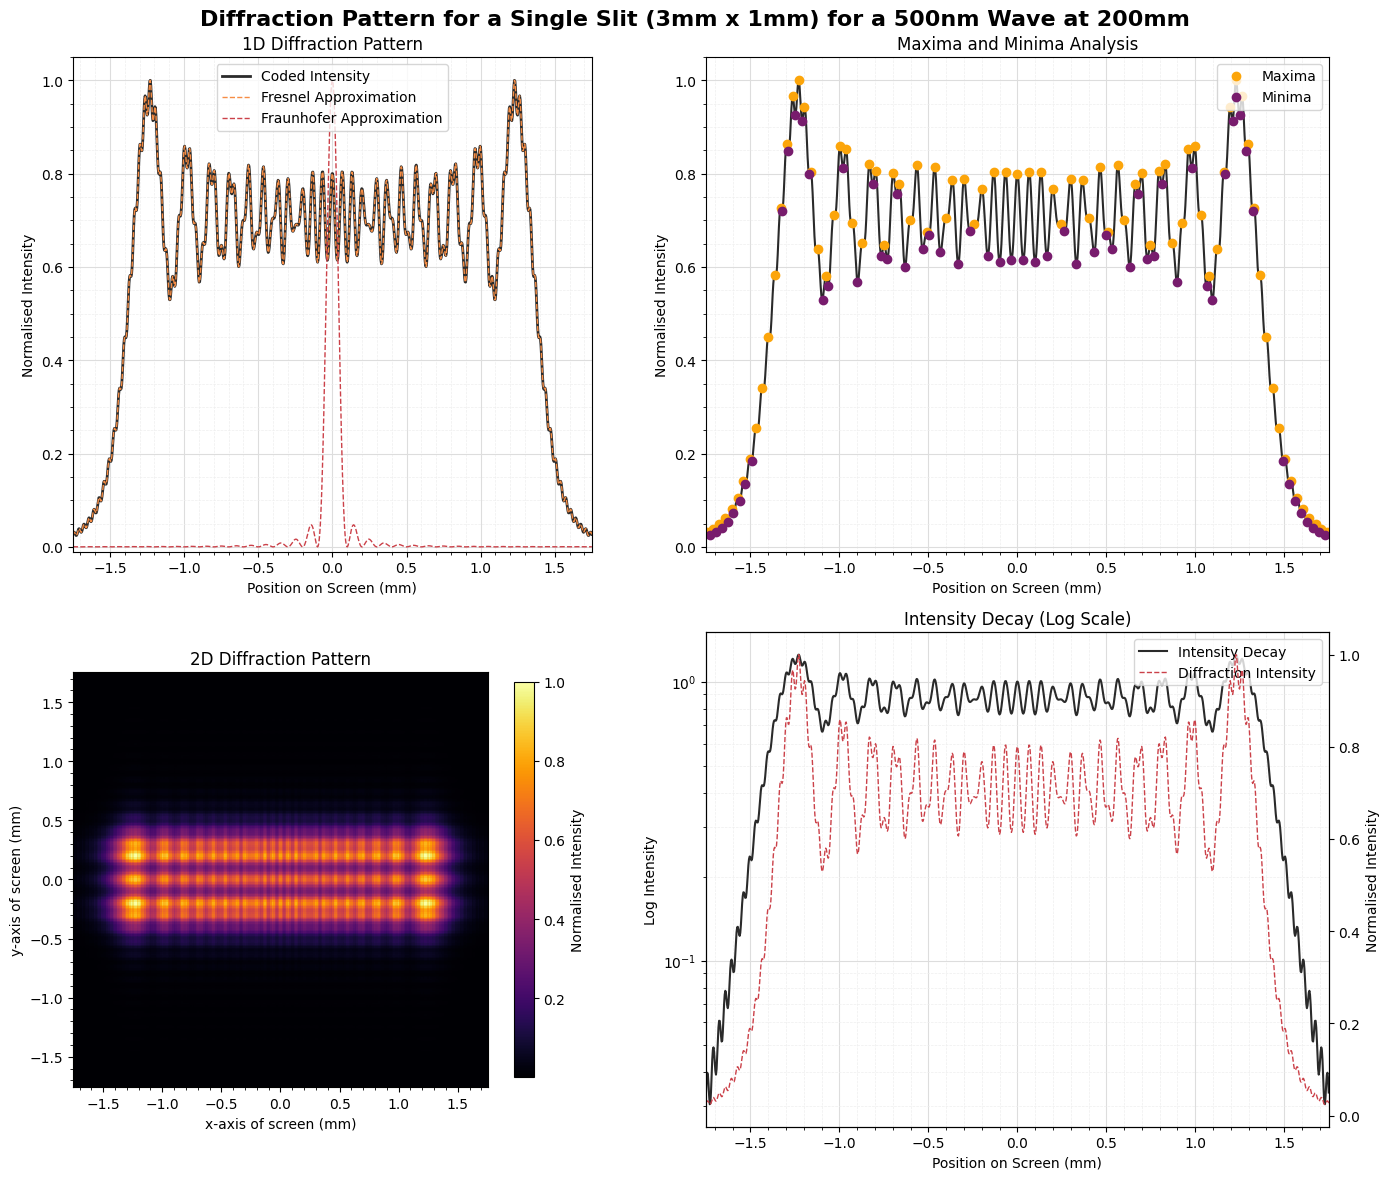

In [23]:
# Wave Equation and Properties

w, h = 3e-3, 1e-3
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 300, 900
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = (np.abs(xx_ap) <= w/2) & (np.abs(yy_ap) <= h/2)

xx_ap_srect = xx_ap[mask].ravel()
yy_ap_srect = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_srect, yy_ap_srect), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def fraun_srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000): 

    screen = np.linspace(screen[0], screen[1], points) 
    
    theta = np.arctan(screen / L) 
    beta = (np.pi * h / lam) * np.sin(theta) 
    
    I_fraun = (np.sinc(beta/np.pi)**2)
    I_fraun /= I_fraun.max() 

    return screen, I_fraun

def fresnel_srect_1d(screen=(-1.75e-3, 1.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)
    factor = (np.exp(1j * k * L)) / (1j * lam * L) # Fresnel Approximation 

    xp = aperture_points[:,0]
    yp = aperture_points[:,1]

    E_theory = np.zeros_like(screen, dtype=complex)
    for i, x in enumerate(screen):
        phase = np.exp((1j * k)/(2 * L) * ((x - xp)**2 + yp**2)) # Fresnel Approximation (Integral Part)
        E = phase * area
        E_theory[i] = factor * E.sum()

    I_fresnel = (np.abs(E_theory)**2)
    I_fresnel /= I_fresnel.max()

    return screen, I_fresnel

def srect_2d(screen=(-1.75e-3, 1.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = srect_1d()
screen, I1DF = fresnel_srect_1d()
screen, I1DFh = fraun_srect_1d()
X, Y, I2D = srect_2d()

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Pattern for a Single Slit (3mm x 1mm) for a 500nm Wave at 200mm', fontsize=16, fontweight='bold')

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=2, label='Coded Intensity')
axes[0,0].plot(screen * 1e3, I1DF, '--', color='#f68d45', linewidth=1, label='Fresnel Approximation')
axes[0,0].plot(screen * 1e3, I1DFh, '--', color='#cb4149', linewidth=1, label='Fraunhofer Approximation')

axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([-0.01, 1.05])
axes[0,0].set_xlim([-1.75, 1.75])

axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,0].legend(loc='upper center')

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto', cmap='inferno')
axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], 'o', color="#fca50a", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], 'o', color="#781c6d", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([-0.01, 1.05])
axes[0,1].set_xlim([-1.75, 1.75])

axes[0,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Intensity Decay Log Plot; bottom right
centre = np.argmin(np.abs(screen))
centre_peak = I1D[centre]

I1D_norm = I1D / centre_peak

mask = I1D_norm > 1e-12

ax_log = axes[1,1]

ax_log.semilogy(screen * 1e3, I1D_norm[mask], color="#2A2A2A", linewidth=1.5, label='Intensity Decay')
ax_log.set_ylabel('Log Intensity')
ax_log.tick_params(axis='y')

ax_lin = ax_log.twinx()
ax_lin.plot(screen * 1e3, I1D, '--', color='#cb4149', linewidth=1, label='Diffraction Intensity')
ax_lin.set_ylabel('Normalised Intensity')
ax_lin.tick_params(axis='y')

ax_log.set_xlabel('Position on Screen (mm)')
ax_log.set_title('Intensity Decay (Log Scale)')
ax_log.set_xlim([-1.75,1.75])

ax_log.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax_log.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax_log.minorticks_on()

lines1, labels1 = ax_log.get_legend_handles_labels()
lines2, labels2 = ax_lin.get_legend_handles_labels()
ax_log.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()

# Double Slit

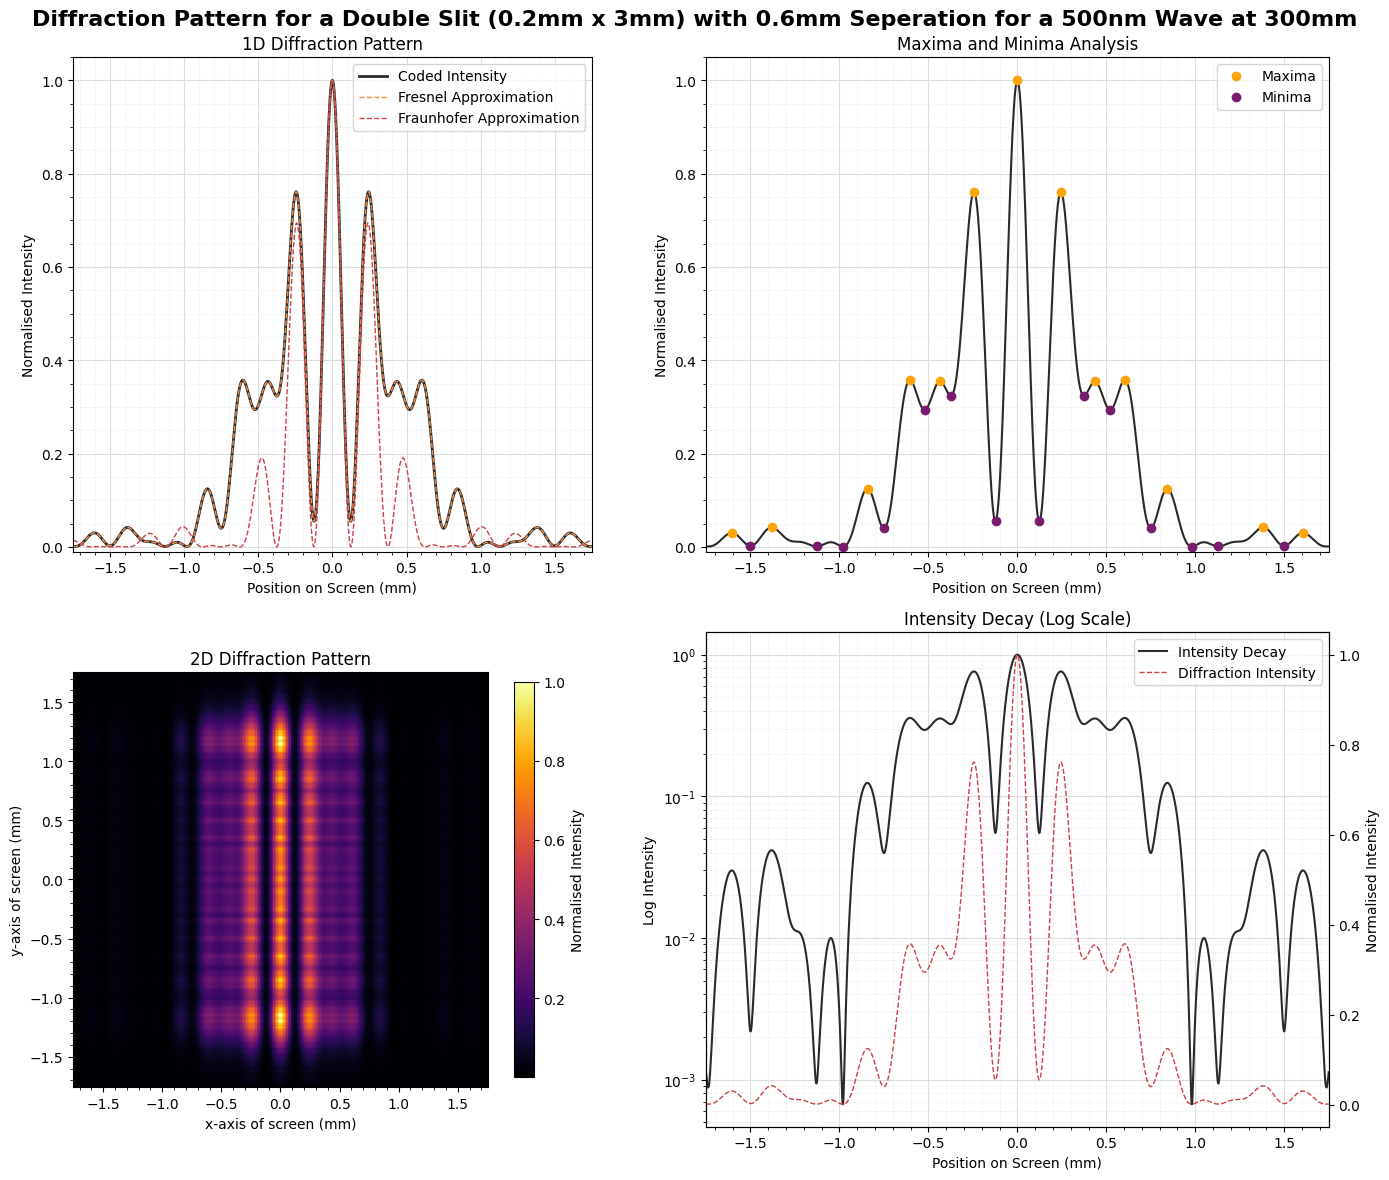

In [22]:
# Wave Equation and Properties

w, h = 0.2e-3, 3e-3
sep = 0.6e-3 # Distance between slits
L = 300e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 550, 1045 # Ratio ny = 1.9 * nx
x_ap = np.linspace(-(sep + w), (sep + w), nx)
y_ap = np.linspace(-h/2, h/2, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

mask_s1 = (np.abs(xx_ap + sep/2) <= w/2) & (np.abs(yy_ap) <= h/2)
mask_s2 = (np.abs(xx_ap - sep/2) <= w/2) & (np.abs(yy_ap) <= h/2)
dmask = mask_s1 | mask_s2

xx_ap_drect = xx_ap[dmask].ravel()
yy_ap_drect = yy_ap[dmask].ravel()

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

aperture_points = np.stack((xx_ap_drect, yy_ap_drect), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def drect_1d(screen=(-1.75e-3, 1.75e-3), points=1500):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def fraun_drect_1d(screen=(-1.75e-3, 1.75e-3), points=1500): 

    screen = np.linspace(screen[0], screen[1], points) 
    
    theta = np.arctan(screen / L) 
    beta = (np.pi * w / lam) * np.sin(theta) 
    alpha = (np.pi * sep / lam) * np.sin(theta) 
    
    I_fraun = (np.sinc(beta/np.pi)**2) * (np.cos(alpha)**2) 
    I_fraun /= I_fraun.max() 

    return screen, I_fraun

def fresnel_drect_1d(screen=(-1.75e-3, 1.75e-3), points=1500):

    screen = np.linspace(screen[0], screen[1], points)
    factor = (np.exp(1j * k * L)) / (1j * lam * L) # Fresnel Approximation 

    xp = aperture_points[:,0]
    yp = aperture_points[:,1]

    E_theory = np.zeros_like(screen, dtype=complex)
    for i, x in enumerate(screen):
        phase = np.exp((1j * k)/(2 * L) * ((x - xp)**2 + yp**2)) # Fresnel Approximation (Integral Part)
        E = phase * area
        E_theory[i] = factor * E.sum()

    I_fresnel = (np.abs(E_theory)**2)
    I_fresnel /= I_fresnel.max()

    return screen, I_fresnel

def drect_2d(screen=(-1.75e-3, 1.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = drect_1d()
screen, I1DF = fresnel_drect_1d()
screen, I1DFh = fraun_drect_1d()
X, Y, I2D = drect_2d()

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Pattern for a Double Slit (0.2mm x 3mm) with 0.6mm Seperation for a 500nm Wave at 300mm', fontsize=16, fontweight='bold')

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=2, label='Coded Intensity')
axes[0,0].plot(screen * 1e3, I1DF, '--', color='#f68d45', linewidth=1, label='Fresnel Approximation')
axes[0,0].plot(screen * 1e3, I1DFh, '--', color='#cb4149', linewidth=1, label='Fraunhofer Approximation')

axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([-0.01, 1.05])
axes[0,0].set_xlim([-1.75, 1.75])

axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,0].legend()

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto', cmap='inferno')
axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], 'o', color="#fca50a", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], 'o', color="#781c6d", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([-0.01, 1.05])
axes[0,1].set_xlim([-1.75, 1.75])

axes[0,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Intensity Decay Log Plot; bottom right
centre = np.argmin(np.abs(screen))
centre_peak = I1D[centre]

I1D_norm = I1D / centre_peak

mask = I1D_norm > 1e-12

ax_log = axes[1,1]

ax_log.semilogy(screen * 1e3, I1D_norm[mask], color="#2A2A2A", linewidth=1.5, label='Intensity Decay')
ax_log.set_ylabel('Log Intensity')
ax_log.tick_params(axis='y')

ax_lin = ax_log.twinx()
ax_lin.plot(screen * 1e3, I1D, '--', color='#cb4149', linewidth=1, label='Diffraction Intensity')
ax_lin.set_ylabel('Normalised Intensity')
ax_lin.tick_params(axis='y')

ax_log.set_xlabel('Position on Screen (mm)')
ax_log.set_title('Intensity Decay (Log Scale)')
ax_log.set_xlim([-1.75,1.75])

ax_log.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax_log.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax_log.minorticks_on()

lines1, labels1 = ax_log.get_legend_handles_labels()
lines2, labels2 = ax_lin.get_legend_handles_labels()
ax_log.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()

# Circular Aperture

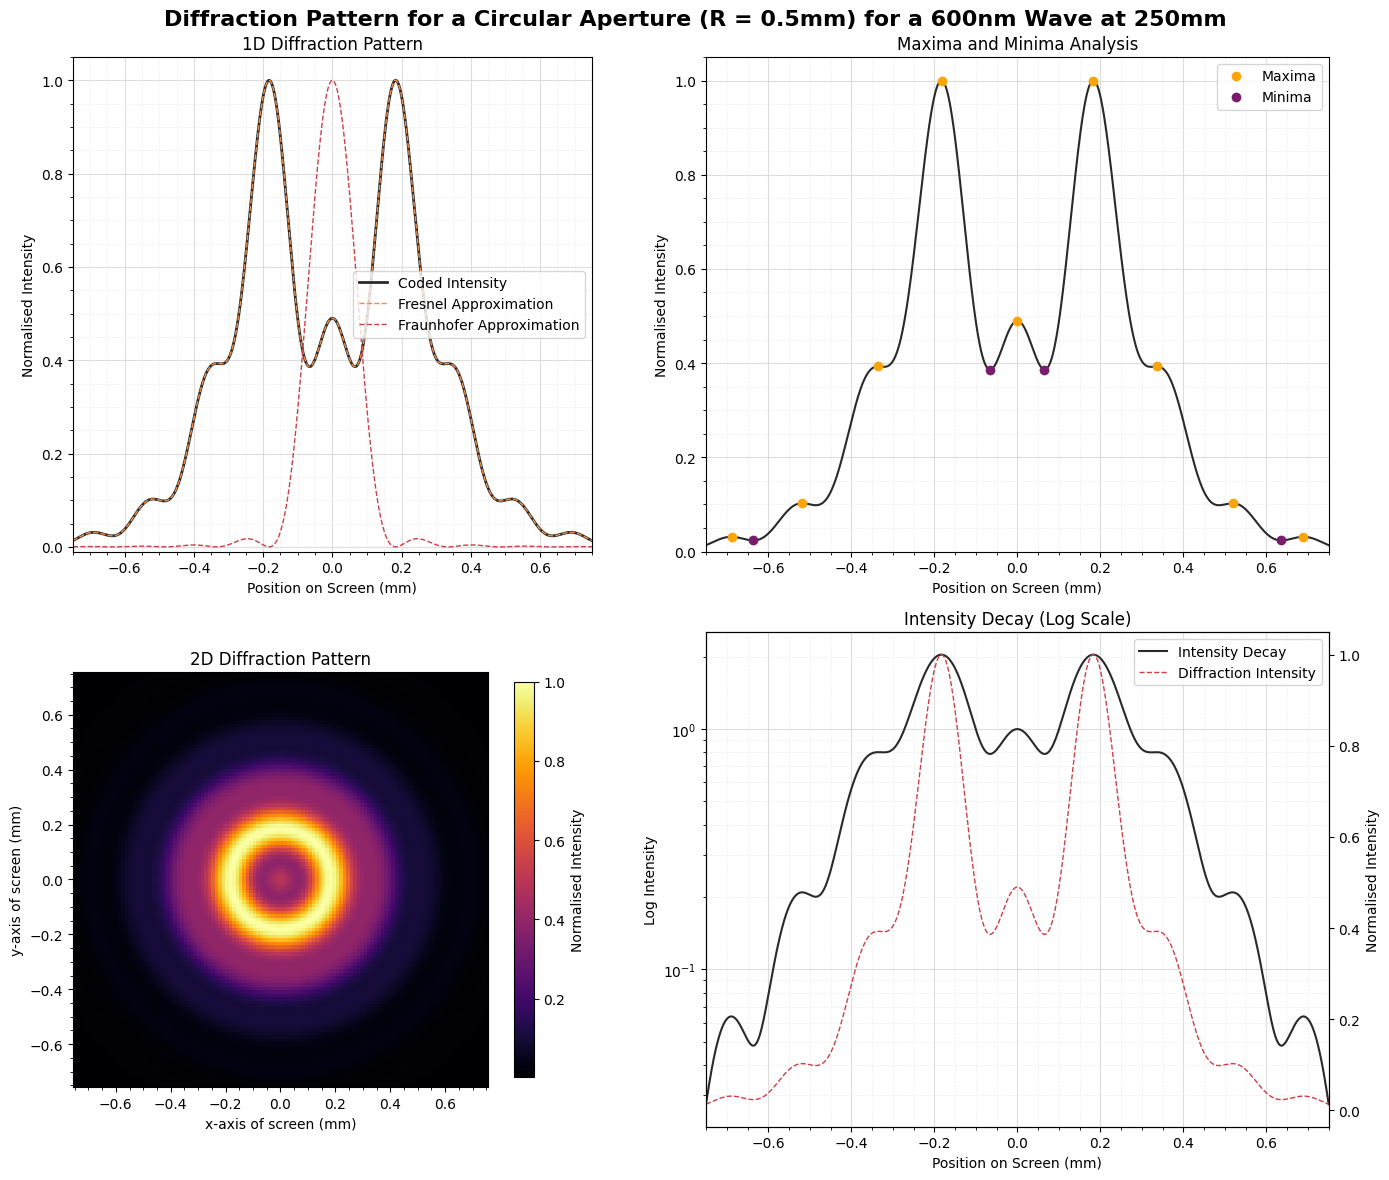

In [ ]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def fraun_circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)

    theta = screen / L # Small angle approximation
    q = k * R * theta
    
    with np.errstate(divide='ignore', invalid='ignore'):
        I_fraun = ((2 * j1(q)) / q)**2

    I_fraun = np.where(np.abs(q) < 1e-12, 1, I_fraun)
    I_fraun /= I_fraun.max()
    
    return screen, I_fraun

def fresnel_circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)

    factor = (np.exp(1j * k * L) / (1j * lam * L)) # Fresnel Approximation

    xp = aperture_points[:,0]
    yp = aperture_points[:,1]

    E_theory = np.zeros_like(screen, dtype=complex)
    for i, x in enumerate(screen):
        phase = np.exp((1j * k)/(2 * L) * ((x - xp)**2 + yp**2)) # Fresnel Approximation (Integral Part)
        E = phase * area
        E_theory[i] = factor * E.sum()

    I_fresnel = (np.abs(E_theory)**2)
    I_fresnel /= I_fresnel.max()

    return screen, I_fresnel

def circ_2d(screen=(-0.75e-3, 0.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = circ_1d()
screen, I1DF = fresnel_circ_1d()
screen, I1DFh = fraun_circ_1d()
X, Y, I2D = circ_2d(screen_res=1.25e-5)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Pattern for a Circular Aperture (R = 0.5mm) for a 500nm Wave at 200mm', fontsize=16, fontweight='bold')

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=2, label='Coded Intensity')
axes[0,0].plot(screen * 1e3, I1DF, '--', color='#f68d45', linewidth=1, label='Fresnel Approximation')
axes[0,0].plot(screen * 1e3, I1DFh, '--', color='#cb4149', linewidth=1, label='Fraunhofer Approximation')

axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([-0.01, 1.05])
axes[0,0].set_xlim([-0.75, 0.75])

axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,0].legend()

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto', cmap='inferno')

axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")

fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#2A2A2A', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], 'o', color="#fca50a", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], 'o', color="#781c6d", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([0, 1.05])
axes[0,1].set_xlim([-0.75, 0.75])

axes[0,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Intensity Decay Log Plot; bottom right
centre = np.argmin(np.abs(screen))
centre_peak = I1D[centre]

I1D_norm = I1D / centre_peak

mask = I1D_norm > 1e-12

ax_log = axes[1,1]

ax_log.semilogy(screen * 1e3, I1D_norm[mask], color="#2A2A2A", linewidth=1.5, label='Intensity Decay')
ax_log.set_ylabel('Log Intensity')
ax_log.tick_params(axis='y')

ax_lin = ax_log.twinx()
ax_lin.plot(screen * 1e3, I1D, '--', color='#cb4149', linewidth=1, label='Diffraction Intensity')
ax_lin.set_ylabel('Normalised Intensity')
ax_lin.tick_params(axis='y')

ax_log.set_xlabel('Position on Screen (mm)')
ax_log.set_title('Intensity Decay (Log Scale)')
ax_log.set_xlim([-0.75, 0.75])

ax_log.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax_log.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax_log.minorticks_on()

lines1, labels1 = ax_log.get_legend_handles_labels()
lines2, labels2 = ax_lin.get_legend_handles_labels()
ax_log.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()